# Installed Capacity by Technology
Stacked bar charts of `TotalCapacityAnnual` (GW) per country and scenario.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')

In [18]:
# ── Configuration ─────────────────────────────────────────────────────────────
SCENARIOS = {
    'REF' : 'results/NamiraN_MSc_REF',
    # 'NECP': 'results/NamiraN_MSc_NECP',   # uncomment when ready
}

PLOT_YEARS = [2015, 2018, 2021, 2024, 2027, 2030, 2033, 2036, 2039, 2042, 2045, 2048, 2050]

COUNTRIES = [
    'AT','BE','DE','DK','EE','FI',
    'FR','LT','LU','LV','NL','NO',
    'PL','SE','UK'
]

COUNTRY_NAMES = {
    'AT':'Austria',     'BE':'Belgium',      'DE':'Germany',     
    'DK':'Denmark',     'EE':'Estonia',      'FI':'Finland',
    'FR':'France',      'LT':'Lithuania',    'LU':'Luxembourg',  
    'LV':'Latvia',      'NL':'Netherlands',  'NO':'Norway',
    'PL':'Poland',      'SE':'Sweden',       'UK':'United Kingdom'
}

# Fuel codes (chars 2-3 of technology name) and display labels
FUEL_MAP = {
    'BF': 'BF',  # Biofuel
    'BM': 'BM',  # Biomass
    'CO': 'CO',  # Coal
    'GO': 'GO',  # Geothermal
    'HF': 'HF',  # Heavy fuel / Oil
    'HY': 'HY',  # Hydro
    'NG': 'NG',  # Natural gas
    'NU': 'NU',  # Nuclear
    'OC': 'OC',  # Ocean
    'SO': 'SO',  # Solar
    'WI': 'WI',  # Wind
    'WS': 'WS',  # Waste
}

# Colours matching reference figure style
FUEL_COLORS = {
    'BF': '#9DC3E6',  # light blue
    'BM': '#4472C4',  # blue
    'CO': '#FF0000',  # red
    'GO': '#70AD47',  # green
    'HF': '#A9D18E',  # light green
    'HY': '#7030A0',  # purple
    'NG': '#00B0F0',  # cyan
    'NU': '#FFC000',  # orange
    'OC': '#002060',  # dark navy
    'SO': '#203864',  # dark blue
    'WI': '#843C00',  # dark brown
    'WS': '#375623',  # dark green
}

In [19]:
def load_capacity(scenarios):
    """Load TotalCapacityAnnual for all scenarios into one DataFrame."""
    dfs = []
    for scen_label, scen_path in scenarios.items():
        path = os.path.join(scen_path, 'results_csv', 'TotalCapacityAnnual.csv')
        df = pd.read_csv(path)
        df['scenario'] = scen_label
        dfs.append(df)
    df = pd.concat(dfs, ignore_index=True)

    # Parse technology name
    df['region']    = df['TECHNOLOGY'].str[0:2]
    df['fuel']      = df['TECHNOLOGY'].str[2:4]
    df['tech_type'] = df['TECHNOLOGY'].str[4:6]

    # Drop interconnection (EL) and dummy (00) technologies
    df = df[(df['fuel'] != 'EL') & (df['tech_type'] != '00')]

    # Keep only known fuel types
    df = df[df['fuel'].isin(FUEL_MAP)]

    return df


def build_capacity_df(df, country, years):
    """Return a (year x fuel) DataFrame of total capacity in GW for a country."""
    sub = df[(df['region'] == country) & (df['YEAR'].isin(years))]
    pivot = (
        sub.groupby(['scenario', 'YEAR', 'fuel'])['VALUE']
        .sum()
        .reset_index()
        .pivot_table(index=['scenario', 'YEAR'], columns='fuel', values='VALUE', fill_value=0)
    )
    # Ensure all fuel columns exist
    for f in FUEL_MAP:
        if f not in pivot.columns:
            pivot[f] = 0.0
    return pivot[list(FUEL_MAP.keys())]


cap_df = load_capacity(SCENARIOS)
print(f"Loaded capacity data: {len(cap_df):,} rows")
print(f"Years: {sorted(cap_df['YEAR'].unique())[:5]} ... {sorted(cap_df['YEAR'].unique())[-3:]}")
cap_df.head()

Loaded capacity data: 11,224 rows
Years: [2015, 2016, 2017, 2018, 2019] ... [2058, 2059, 2060]


,REGION,TECHNOLOGY,YEAR,VALUE,scenario,region,fuel,tech_type
0,REGION1,ATBFHPFH1,2015,0.02941,REF,AT,BF,HP
1,REGION1,ATBFHPFH1,2016,0.02941,REF,AT,BF,HP
2,REGION1,ATBFHPFH1,2017,0.02941,REF,AT,BF,HP
3,REGION1,ATBFHPFH1,2018,0.02941,REF,AT,BF,HP
4,REGION1,ATBFHPFH1,2019,0.02941,REF,AT,BF,HP


Saved to results/capacity_all_countries.png


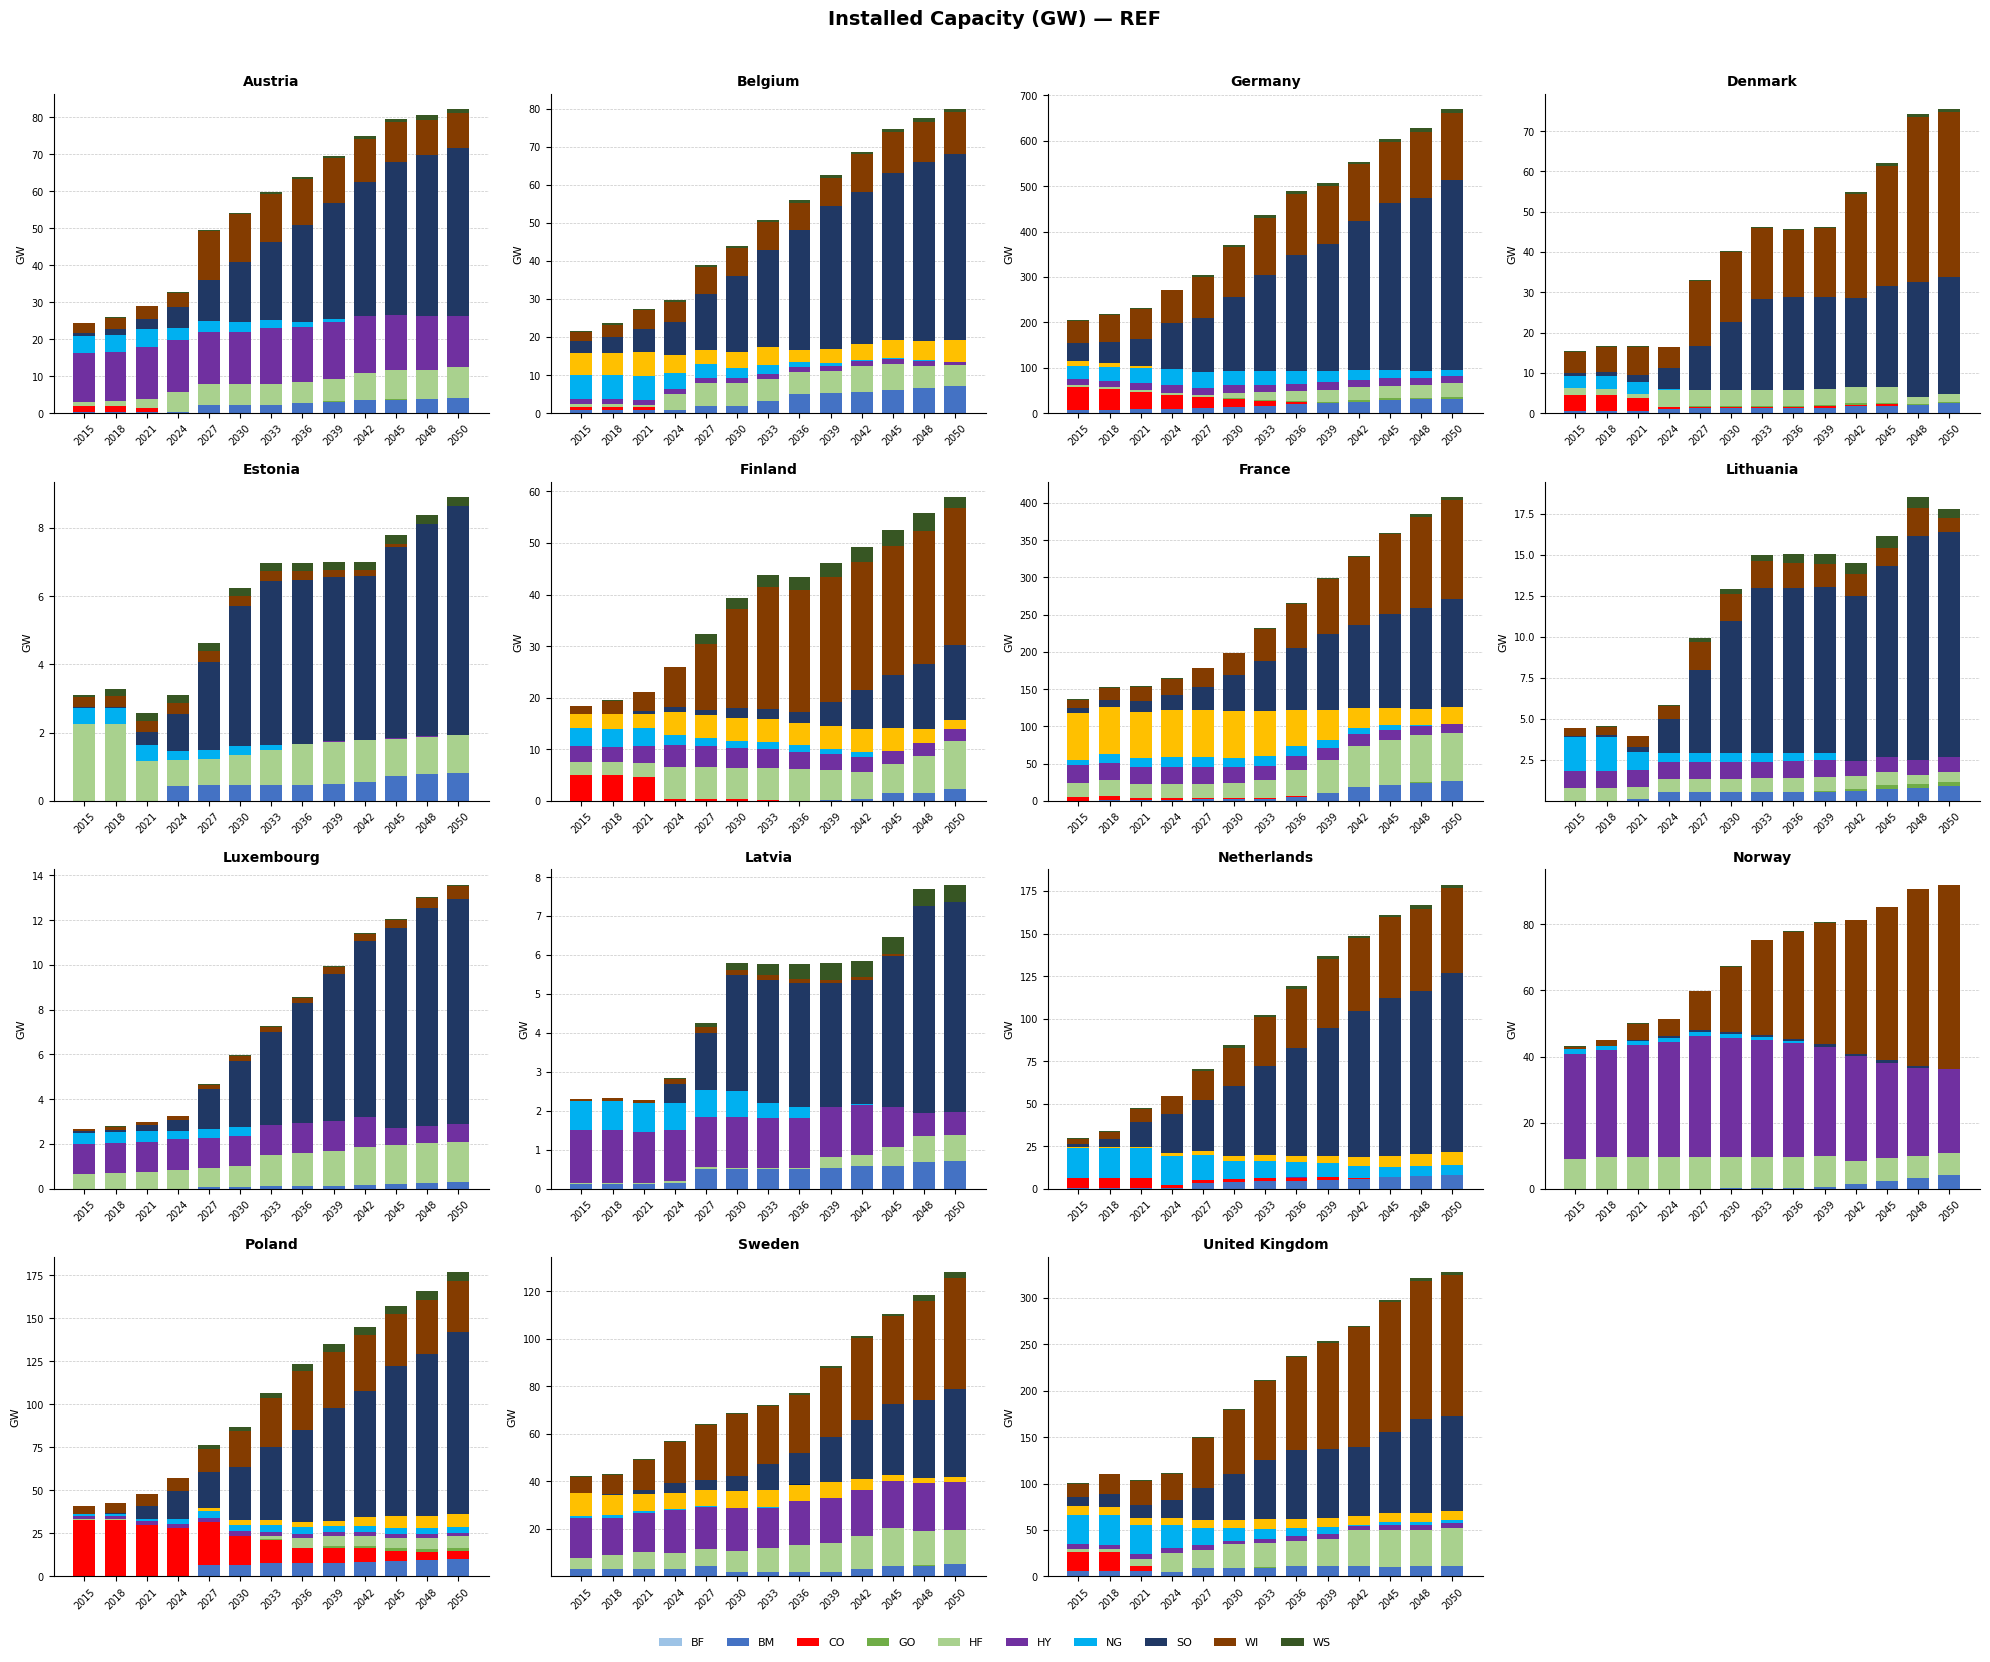

In [20]:
def plot_capacity(df, countries, years, scenarios, save_path=None, ncols=4):
    """Plot stacked bar charts of installed capacity for each country."""
    nrows = int(np.ceil(len(countries) / ncols))
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5 * ncols, 4 * nrows),
                             sharey=False)
    axes = axes.flatten()

    scen_labels = list(scenarios.keys())
    bar_width   = 0.7 / len(scen_labels)
    x           = np.arange(len(years))
    fuels       = list(FUEL_MAP.keys())

    for ax_idx, country in enumerate(countries):
        ax = axes[ax_idx]
        pivot = build_capacity_df(df, country, years)

        for s_idx, scen in enumerate(scen_labels):
            if scen not in pivot.index.get_level_values('scenario'):
                continue
            data = pivot.xs(scen, level='scenario').reindex(years, fill_value=0)
            offset = (s_idx - (len(scen_labels) - 1) / 2) * bar_width
            bottom = np.zeros(len(years))

            for fuel in fuels:
                vals = data[fuel].values
                if vals.sum() < 1e-6:
                    continue
                label = FUEL_MAP[fuel] if s_idx == 0 else '_nolegend_'
                ax.bar(x + offset, vals, bar_width,
                       bottom=bottom,
                       color=FUEL_COLORS[fuel],
                       label=label,
                       edgecolor='none')
                bottom += vals

        ax.set_title(COUNTRY_NAMES.get(country, country), fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(years, rotation=45, fontsize=7)
        ax.set_ylabel('GW', fontsize=8)
        ax.yaxis.set_tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
        ax.set_axisbelow(True)

    # Hide unused subplots
    for ax_idx in range(len(countries), len(axes)):
        axes[ax_idx].set_visible(False)

    # Legend from first subplot
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center',
               ncol=len(fuels), fontsize=8,
               frameon=False, bbox_to_anchor=(0.5, -0.02))

    scen_str = ' vs '.join(scen_labels)
    fig.suptitle(f'Installed Capacity (GW) — {scen_str}',
                 fontsize=14, fontweight='bold', y=1.01)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved to {save_path}')
    plt.show()


plot_capacity(
    cap_df, COUNTRIES, PLOT_YEARS, SCENARIOS,
    save_path='results/capacity_all_countries.png'
)

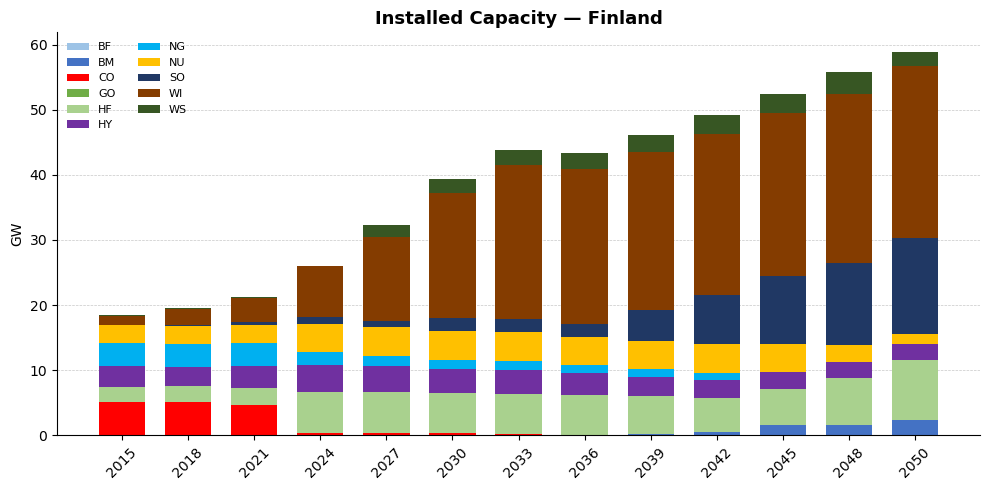

In [23]:
# ── Single country detailed view ──────────────────────────────────────────────
def plot_single_country(df, country, years, scenarios):
    fig, ax = plt.subplots(figsize=(10, 5))
    scen_labels = list(scenarios.keys())
    bar_width   = 0.7 / len(scen_labels)
    x           = np.arange(len(years))
    fuels       = list(FUEL_MAP.keys())
    pivot       = build_capacity_df(df, country, years)

    for s_idx, scen in enumerate(scen_labels):
        if scen not in pivot.index.get_level_values('scenario'):
            continue
        data   = pivot.xs(scen, level='scenario').reindex(years, fill_value=0)
        offset = (s_idx - (len(scen_labels) - 1) / 2) * bar_width
        bottom = np.zeros(len(years))
        for fuel in fuels:
            vals = data[fuel].values
            if vals.sum() < 1e-6:
                continue
            label = f'{FUEL_MAP[fuel]} ({scen})' if len(scen_labels) > 1 else FUEL_MAP[fuel]
            ax.bar(x + offset, vals, bar_width, bottom=bottom,
                   color=FUEL_COLORS[fuel], label=label, edgecolor='none')
            bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.set_ylabel('GW')
    ax.set_title(f'Installed Capacity — {COUNTRY_NAMES.get(country, country)}',
                 fontsize=13, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc='upper left', fontsize=8, frameon=False, ncol=2)
    plt.tight_layout()
    plt.show()


# Change country code to inspect any country
plot_single_country(cap_df, 'FI', PLOT_YEARS, SCENARIOS)